# Using Logarithmic Regression to Identify Top Juniors

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import scipy.stats as ss
from sklearn.linear_model import LinearRegression

import sys
sys.path.insert(0, '../load_data')
from load import load_stats, load_history

pd.options.mode.chained_assignment = None

## Load Data

In [81]:
players = load_stats()
history = load_history()

## Clean Data

In [ ]:
age_history = history.merge(players[['Database#', 'Date of Birth']], how='left')
history['tournament age'] = (history['Start Date'] - age_history['Date of Birth']).dt.days / 365

In [83]:
# find number of days since first tournament for every tournament for every player
def start_date(player):
    rhist = history[history['Database#'] == player['Database#']]
    return rhist['Start Date'].iloc[-1]

start_dates = players.apply(start_date, axis=1)
start_dates.index = players['Database#']
history['days played'] = (history['Start Date'].reset_index(drop=True) - start_dates[history['Database#']].reset_index(drop=True)).dt.days
history['log days played'] = np.log1p(history['days played'])

In [84]:
# filter out people who don't have initial ratings, start dates, or ages
history = history.dropna(subset=["Initial Rating", "Start Date", "days played"])
players = players[players['USATT#'].isin(history['USATT#'])]
history = history[history['USATT#'].isin(players['USATT#'])]

In [86]:
def rvalue(player):
    rhist = history[history['Database#'] == player['Database#']]
    if len(rhist) < 5:
        return pd.NA
    if len(rhist[rhist["tournament age"] < 19]) < 5:
        return pd.NA

    data = rhist[['log days played', 'Initial Rating']]
    reg = ss.linregress(data['log days played'], data['Initial Rating'])
    
    return reg.rvalue

players["r value"] = players.apply(rvalue, axis=1)

In [93]:
players[players["r value"] > 0.7]

,Rank,First Name,Last Name,Database#,USATT#,Location,Home Club,Tournament Rating,Last Played Tournament,League Rating,...,State,Zip,Gender,Date of Birth,Expiration Date,Max Rating,Age,Tournaments Played,standard error,r value
3,4,Kanak,Jha,3431,72193,"Milpitas, CA",888 Table Tennis Center,2806,2024-07-07,2737,...,CA,95035,M,2000-06-19,2100-02-28,2806.0,8862 days,67,35.489941,0.868043
9,10,Nikhil,Kumar,3998,84326,"San Jose, CA",888 Table Tennis Center,2753,2024-09-02,2601,...,CA,95125,M,2003-01-01,2024-11-17,2779.0,7936 days,91,24.504351,0.917329
27,28,Aditya,Sareen,119074,218074,"West Windsor, NJ",PINGPOD,2676,2024-08-25,2497,...,NJ,8550,M,2008-04-28,2024-12-16,2703.0,5992 days,131,16.228918,0.937896
30,31,Patryk,Zyworonek,9197,96307,"Des Plaines, IL",Experior Table Tennis Club,2661,2023-12-21,2245,...,IL,60016,M,2009-02-24,2099-11-23,2661.0,5690 days,76,40.453068,0.81094
36,37,Yijun,Feng,2116,35040,"Long Island City, NY",PINGPOD,2650,2024-08-25,2579,...,NY,11101,M,1997-02-12,2100-02-28,2732.0,10085 days,79,8.114556,0.967933
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10352,10353,Mehul,Ajmera,177264,1177264,"Dublin, CA",NaN,101,2024-06-22,149,...,CA,94568,M,2009-09-16,2024-10-31,101.0,5486 days,7,2.368227,0.938205
10380,10381,Surya,Gayam,176893,275893,"Sunol, CA",NaN,70,2023-06-18,181,...,CA,94586,M,2009-11-02,2024-10-31,96.0,5439 days,5,2.81056,0.958422
10399,10400,Sumedh,Chekka,170375,1170375,"Saratoga, CA",NaN,52,2024-06-22,101,...,CA,95070,M,2009-05-24,2024-11-15,52.0,5601 days,6,1.602524,0.762087
10432,10433,Jules,Mundur,176654,275654,"Pleasanton, CA",Fremont Table Tennis Academy,32,2023-10-09,101,...,CA,94566,M,2008-07-02,2024-09-17,39.0,5927 days,5,1.762121,0.901831


In [ ]:
# valid player defined as players who didn't gain more than 1500 points in their first tournament, have played more than 5 
# tournaments before they turned 19, and have a correlation coefficient of over 0.8
def valid_player(player):
    max_first_tournament = 1500
    min_tournament_count = 5
    min_correlation = 0.75

    rhist = history[history['Database#'] == player['Database#']]
    if len(rhist) == 0:
        return False

    first_tournament = rhist.iloc[-1]
    if not ((first_tournament['Initial Rating'] == 0) and (first_tournament['Final Rating'] <= max_first_tournament) and (len(rhist[(rhist['Start Date'] - player['Date of Birth']).dt.days <= 19*365]) >= min_tournament_count)):
        return False
    
    data = rhist[['days played', 'Initial Rating']]
    data['log days played'] = np.log1p(data['days played'])
    reg = ss.linregress(data['log days played'], data['Initial Rating'])

    return reg.rvalue > min_correlation

# filter out all invalid players
players['Valid Player'] = players.apply(valid_player, axis=1)
valid = players[['Database#', 'Valid Player']]
history = history.merge(valid, how='inner', on='Database#')
players = players[players['Valid Player'] == True].reset_index(drop=True)
history = history[history['Valid Player'] == True].reset_index(drop=True)

In [6]:
# check if tournament is played while player is U19
def junior_tournaments(tournament):
    player = players[players['Database#'] == tournament['Database#']].reset_index(drop=True)
    if len(player) == 0:
        return False
    return (tournament['Start Date'] - player.loc[0, 'Date of Birth']).days <= 19*365

history = history[history.apply(junior_tournaments, axis=1)].reset_index(drop=True)

## Feature Engineering

In [7]:
# age at x rating
def age_by_x(player, r):
    r_hist = history[history['USATT#'] == player['USATT#']]
    scope = r_hist[r_hist['Final Rating'] > r]
    if len(scope) == 0:
        return -1
    return (scope.loc[scope.index[-1], 'Start Date'] - player['Date of Birth']).days

# hit the target rating by u19
def is_top_junior(player, male_rating, female_rating):
    if player['Gender'] == 'M':
        age_by_rating = age_by_x(player, male_rating)
    elif player['Gender'] == 'F':
        age_by_rating = age_by_x(player, female_rating)
    else:
        return pd.NA
    
    if age_by_rating == -1:
        return False
    return age_by_rating < 19*365

players['Top Junior'] = players.apply(is_top_junior, args=(2400, 2200), axis=1)

# scope training to only include people over 19 years old or people who are currently U19 and a top junior
training = players[(players['Top Junior'] == True) | (players['Age'].dt.days > 19*365)]

## Regression Analysis

In [12]:
# logarithmic regression of player rating graph, returns a, b in aln(bx)
def fit_log_reg(player, n_tours=-1, plot=False, axes=None):
    rhist = history[history['Database#'] == player['Database#']].reset_index(drop=True)
    data = rhist[['days played', 'Initial Rating']]
    if n_tours >= 0:
        data = data[-n_tours:]
    data['log days played'] = np.log1p(data['days played'])

    reg = ss.linregress(data['log days played'], data['Initial Rating'])
    a = reg.slope

    if plot:
        b = np.exp(reg.intercept / reg.slope)
        sns.scatterplot(data=data, x='log days played', y='Initial Rating', ax=axes[1], label='Rating History (log)')
        sns.regplot(data=data, x='log days played', y='Initial Rating', label=f'r: {round(reg.rvalue, 4)}', ax=axes[1], scatter=False)
        axes[1].set_xlabel('Days Played (log)')
        axes[1].set_title('Strength of Correlation between Data and Model')
        axes[1].legend()

        x = np.linspace(data['days played'].min(),data['days played'].max(),60)
        y = a * np.log1p(b * x)
        data.plot(kind='line', x='days played', y='Initial Rating', ax=axes[0], label='USATT Rating')
        sns.lineplot(x=x, y=y, ax=axes[0], label=f'Logarithmic Coefficient: {round(a, 4)}')
        axes[0].set_xlabel('Days Played')
        axes[0].set_title('Logarithmic Progression Model')
        axes[0].set_ylim(0, None)
        axes[0].legend()
    
    return a

# logarithmic regression of player rating graph, returns a, b in aln(bx)
def fit_log_b(player, n_tours=-1, plot=False, axes=None):
    rhist = history[history['Database#'] == player['Database#']].reset_index(drop=True)
    data = rhist[['days played', 'Initial Rating']]
    if n_tours >= 0:
        data = data[-n_tours:]
    data['log days played'] = np.log1p(data['days played'])

    reg = ss.linregress(data['log days played'], data['Initial Rating'])
    a = reg.slope
    b = np.exp(reg.intercept / reg.slope)

    if plot:
        b = np.exp(reg.intercept / reg.slope)
        sns.scatterplot(data=data, x='log days played', y='Initial Rating', ax=axes[1], label='Rating History (log)')
        sns.regplot(data=data, x='log days played', y='Initial Rating', label=f'r: {round(reg.rvalue, 4)}', ax=axes[1], scatter=False)
        axes[1].set_xlabel('Days Played (log)')
        axes[1].set_title('Strength of Correlation between Data and Model')
        axes[1].legend()

        x = np.linspace(data['days played'].min(),data['days played'].max(),60)
        y = a * np.log1p(b * x)
        data.plot(kind='line', x='days played', y='Initial Rating', ax=axes[0], label='USATT Rating')
        sns.lineplot(x=x, y=y, ax=axes[0], label=f'Logarithmic Coefficient: {round(a, 4)}')
        axes[0].set_xlabel('Days Played')
        axes[0].set_title('Logarithmic Progression Model')
        axes[0].set_ylim(0, None)
        axes[0].legend()
    
    return b

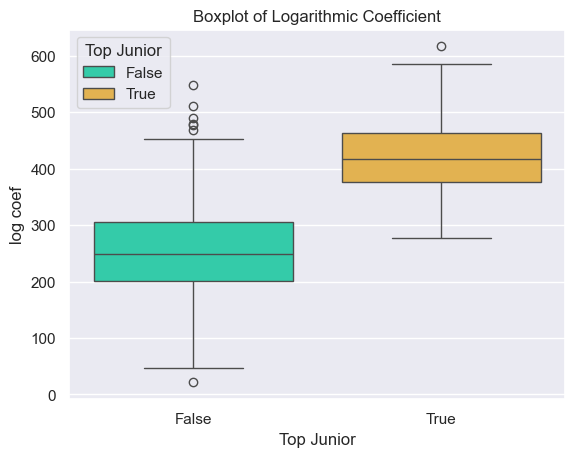

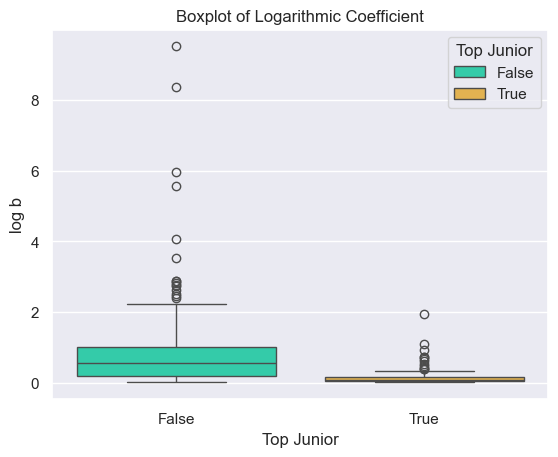

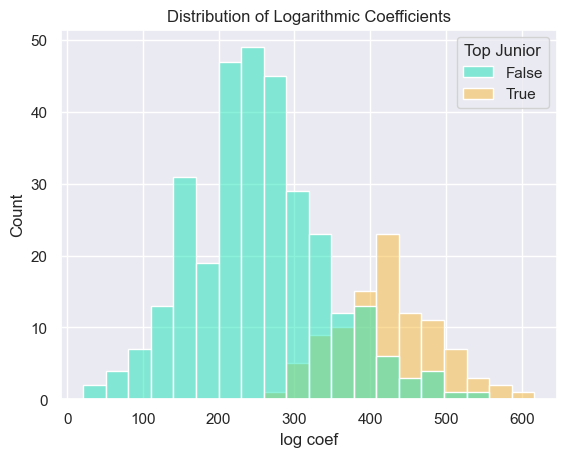

In [ ]:
training['log coef'] = training.apply(fit_log_reg, axis=1).to_list()
training['log b'] = training.apply(fit_log_b, axis=1).to_list()

sns.boxplot(data=training, x='Top Junior', y='log coef', hue='Top Junior', palette='turbo')
plt.title('Boxplot of Logarithmic Coefficient')
plt.show()

sns.boxplot(data=training, x='Top Junior', y='log b', hue='Top Junior', palette='turbo')
plt.title('Boxplot of Logarithmic Coefficient')
plt.show()

sns.histplot(data=training, x='log coef', hue='Top Junior', palette='turbo', bins=20)
plt.title('Distribution of Logarithmic Coefficients')
plt.show()

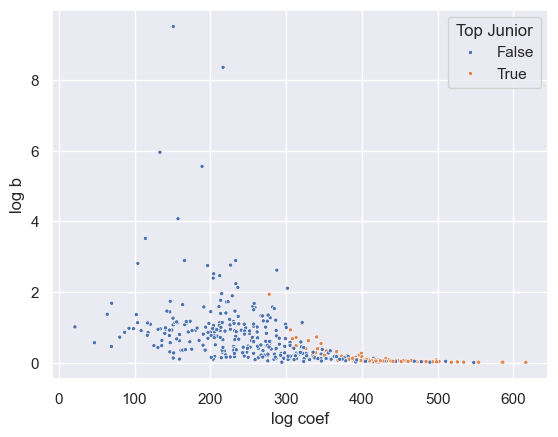

In [ ]:
sns.scatterplot(data=training, x='log coef', y='log b', hue="Top Junior", marker=".")
plt.show()

In [10]:
from scipy.optimize import curve_fit

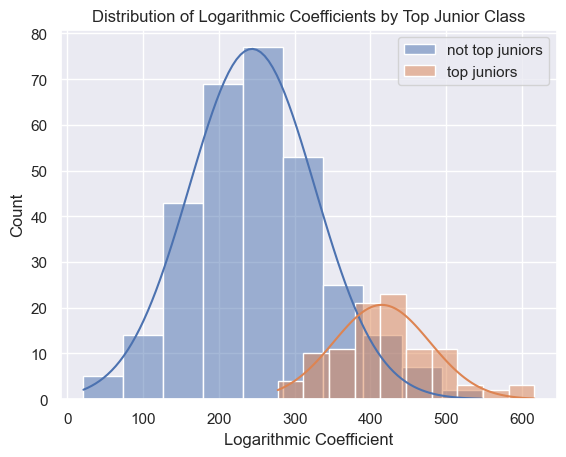

In [11]:
ntj = training[training['Top Junior'] == False]
tj = training[training['Top Junior'] == True]

# fit the parameters of a normal distribution curve using our data
def fit_log_coef_func(x, scale, mu, sigma):
    return scale * np.exp(-0.5 * ((x / 100 - mu) / sigma)**2)

# normal disribution given parameters
def log_coef_func(x, params):
    return params[0] * np.exp(-0.5 * ((x / 100 - params[1]) / params[2])**2)

# fit equation of normal distribution over log coef data for first n tournaments of every player
def fit_log_coef_dist(data, bins, n_tours=-1, label='', plot=False, ax=None):
    data['log coef'] = data.apply(fit_log_reg, axis=1, args=(n_tours,False))
    data['log coef bin'] = pd.cut(data['log coef'], bins)
    data_coefs = data[['log coef', 'log coef bin']].groupby('log coef bin', observed=True).count()
    data_coefs.index = pd.IntervalIndex(data_coefs.index)

    parameters, covariance = curve_fit(fit_log_coef_func, data_coefs.index.mid, data_coefs['log coef'])

    if plot:
        sns.histplot(data=data, x='log coef', bins=bins, alpha=0.5, label=label, ax=ax)
        x = np.linspace(data['log coef'].min(), data['log coef'].max(), 100)
        y = log_coef_func(x, parameters)
        sns.lineplot(x=x, y=y, ax=ax)
        ax.set_xlabel('Logarithmic Coefficient')
        ax.set_ylabel('Count') 
        ax.set_title('Distribution of Logarithmic Coefficients by Top Junior Class')
        ax.legend()
    
    return parameters, data


n = -1
ax = plt.axes()
ntj_params, ntj_n_tours = fit_log_coef_dist(data=ntj, bins=10, plot=True, label='not top juniors', n_tours=n, ax=ax)
tj_params, tj_n_tours = fit_log_coef_dist(data=tj, bins=10, plot=True, label='top juniors', n_tours=n, ax=ax)
plt.show()

In [23]:
players[players['First Name'] == 'Aditya']

,Rank,First Name,Last Name,Database#,USATT#,Location,Home Club,Tournament Rating,Last Played Tournament,League Rating,...,State,Zip,Gender,Date of Birth,Expiration Date,Max Rating,Age,Tournaments Played,Valid Player,Top Junior
2,28,Aditya,Sareen,119074,218074,"West Windsor, NJ",PINGPOD,2676,2024-08-25,2497,...,NJ,8550,M,2008-04-28,2024-12-16,2703.0,5992 days,131,True,True
34,198,Aditya,Godhwani,2474,82768,"Fremont, CA",(TTA) Table Tennis America,2446,2024-07-07,2308,...,CA,94539,M,2003-07-24,2122-12-31,2563.0,7732 days,112,True,True
287,1159,Aditya,Bhaskar Pandit,119523,218523,"Gilbert, AZ",TABLE TENNIS & MORE AZ,2043,2024-08-25,1952,...,AZ,85297,M,2010-11-07,2025-07-22,2043.0,5069 days,56,True,False
325,1336,Aditya,Oak,38831,94602,"Sugar Land, TX",Houston Table Tennis Association Inc.,2012,2024-08-11,2017,...,TX,77479,M,2005-01-12,2025-07-01,2012.0,7194 days,41,True,False
348,1448,Aditya,Chirayath,171089,270089,"Cedar Park, TX",NaN,1988,2024-08-31,1865,...,TX,78613,M,2010-05-08,2025-07-17,1988.0,5252 days,34,True,False
1192,10141,Aditya,Parikh,175604,274604,Stockton,NaN,335,2024-08-31,368,...,NaN,95219,M,2010-10-02,2025-06-15,508.0,5105 days,6,True,False
1202,10304,Aditya,Kota,177504,276504,NaN,NaN,176,2024-08-31,374,...,NaN,NaN,M,2007-12-25,2024-11-10,200.0,6117 days,9,True,False


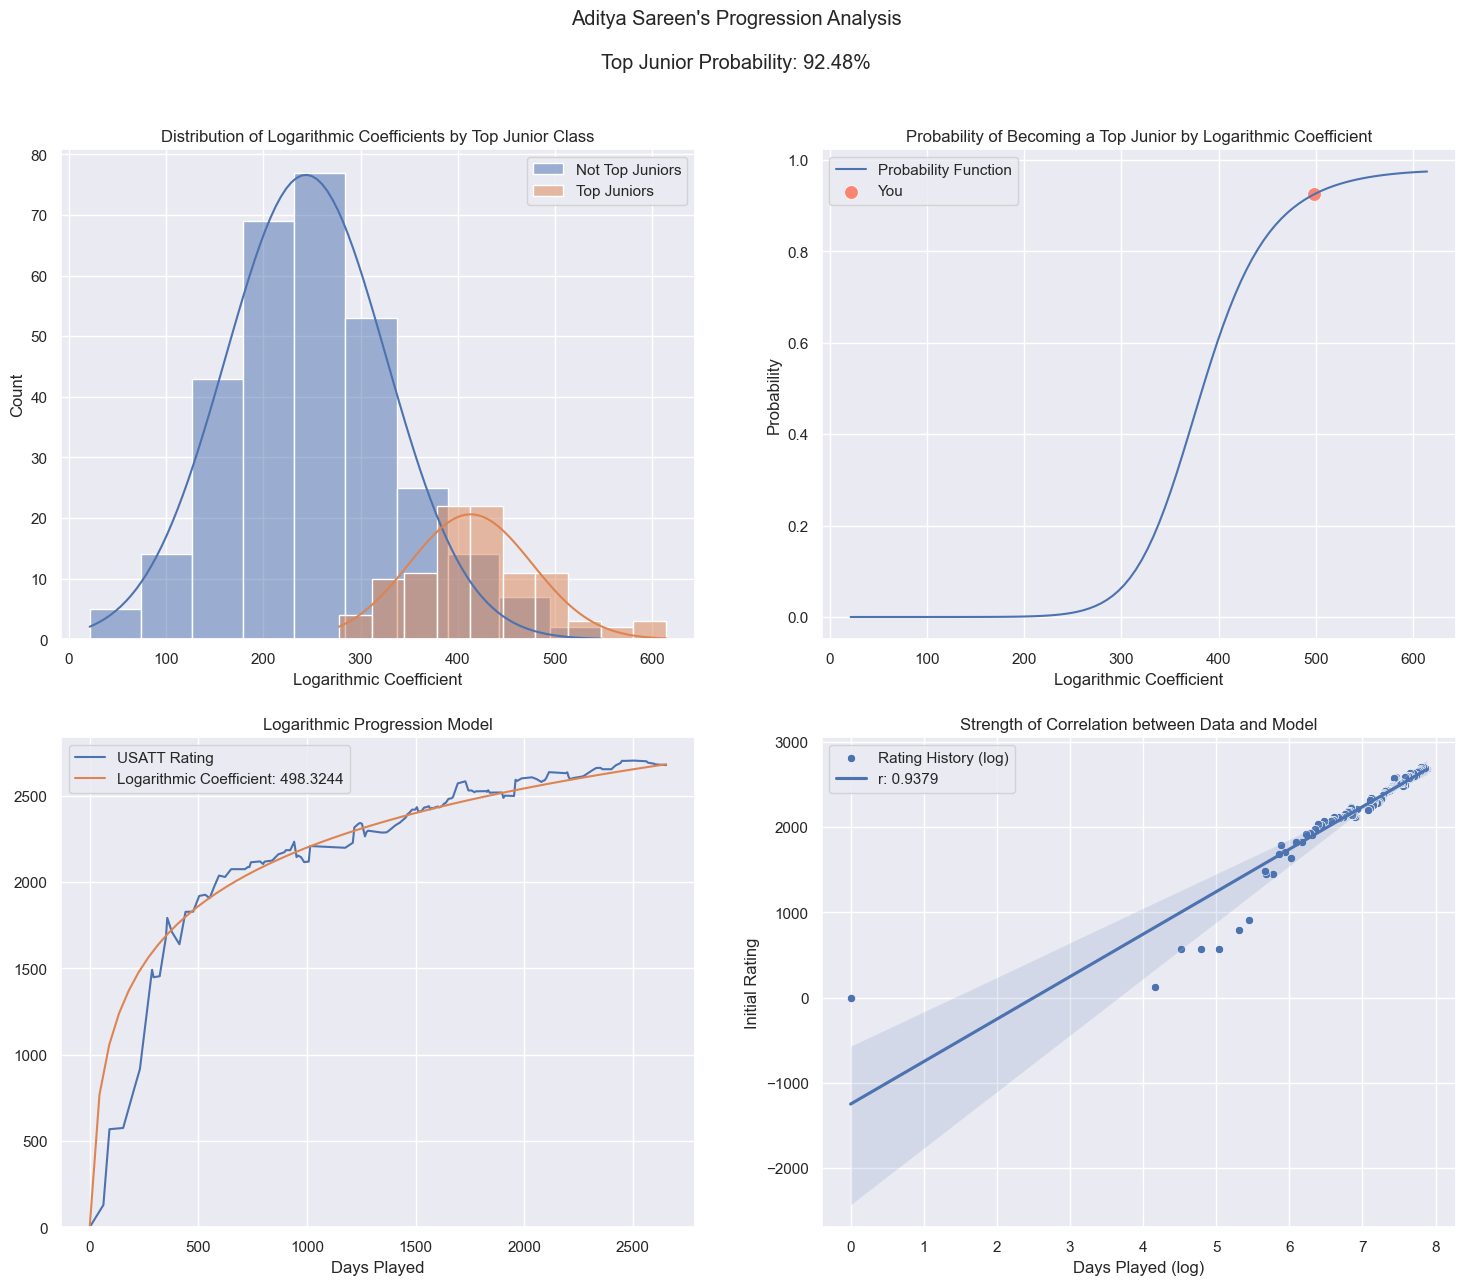

In [26]:
# probability function of becoming top junior given log coef
def top_junior_prob_func(log_coef, tj_params, ntj_params):
    tj_prob = log_coef_func(log_coef, tj_params)
    ntj_prob = log_coef_func(log_coef, ntj_params)
    return tj_prob / (tj_prob + ntj_prob)

# graph top junior probability function for given player, return probability
def top_junior_prob(player):
    rhist = history[history['Database#'] == player['Database#']]
    n_tours = len(rhist)

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    ax = axes[0][0]
    ntj_params, ntj_n_tours = fit_log_coef_dist(data=ntj, bins=10, label='Not Top Juniors', n_tours=n_tours, plot=True, ax=ax)
    tj_params, tj_n_tours = fit_log_coef_dist(data=tj, bins=10, label='Top Juniors', n_tours=n_tours, plot=True, ax=ax)

    min_coef = min(ntj_n_tours['log coef'].min(), tj_n_tours['log coef'].min())
    max_coef = max(ntj_n_tours['log coef'].max(), tj_n_tours['log coef'].max())
    x = np.linspace(min_coef, max_coef, 100)
    y = top_junior_prob_func(x, tj_params, ntj_params)
    player_log_coef = fit_log_reg(player)
    player_prob = top_junior_prob_func(player_log_coef, tj_params, ntj_params)

    name = f'{player['First Name']} {player['Last Name']}'
    fig.suptitle(f"{name}'s Progression Analysis\n\nTop Junior Probability: {round(player_prob * 100, 2)}%")

    ax = axes[0][1]
    sns.lineplot(x=x, y=y, label='Probability Function', ax=ax)
    sns.scatterplot(x=[player_log_coef], y=[player_prob], marker='o', s=100, label='You', color='#FF6347', alpha=0.75, ax=ax)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_xlabel('Logarithmic Coefficient')
    ax.set_ylabel('Probability')
    ax.set_title('Probability of Becoming a Top Junior by Logarithmic Coefficient')
    ax.legend()

    fit_log_reg(player, plot=True, axes=axes[1])
    plt.show()

me = players[players['USATT#'] == 218074].iloc[0]
top_junior_prob(me)

In [35]:
history[(history['tournament age'] < 10)]['Database#'].unique().size

467

In [14]:
# logarithmic regression of 90 day window moving average of player rating graph, returns a, b in aln(bx)
def fit_rolling_log_reg(player, window=90, n_tours=0, plot=False):
    fullhist = history[history['Database#'] == player['Database#']].reset_index(drop=True)
    rhist = fullhist[['days played', 'Initial Rating']]
    rhist['days played'] = pd.to_timedelta(rhist['days played'], 'day')
    rhist.set_index('days played', inplace=True)
    data = rhist.rolling(f'{window}d').mean().reset_index()
    data['days played'] = data['days played'].dt.days
    data = data[-n_tours:]
    data['log days played'] = np.log1p(data['days played'])

    reg = ss.linregress(data['log days played'], data['Initial Rating'])

    a = reg.slope
    b = np.exp(reg.intercept / reg.slope)
    if plot:
        sns.regplot(data=data, x='log days played', y='Initial Rating', label=f'r: {round(reg.rvalue, 4)}')
        plt.legend()
        plt.show()
        
        x = np.arange(0,data['days played'].max(),10)
        y = a * np.log(b * (x + 10))
        data.plot(kind='line', x='days played', y='Initial Rating')
        plt.plot(x, y)
        plt.ylim(0, None)
        plt.show()
    
    return np.array([a, b])

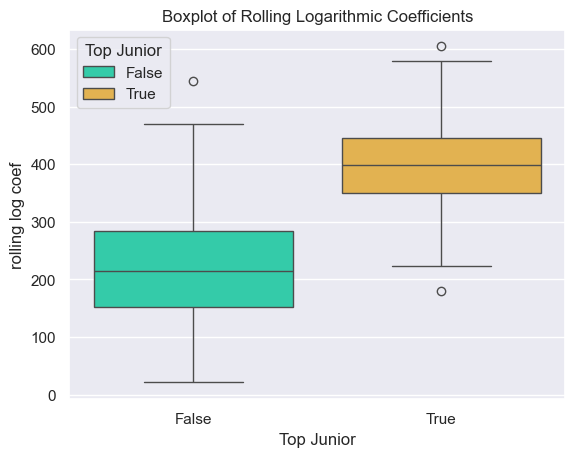

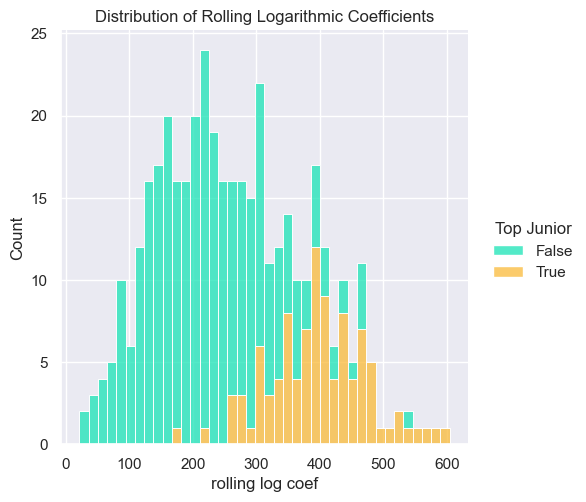

In [15]:
rolling_log_reg = training.apply(fit_rolling_log_reg, axis=1).to_list()
rolling_all_a = [coef[0] for coef in rolling_log_reg]
rolling_all_b = [coef[1] for coef in rolling_log_reg]
training['rolling log coef'] = rolling_all_a
training['rolling log const'] = rolling_all_b

sns.boxplot(data=training, x='Top Junior', y='rolling log coef', hue='Top Junior', palette='turbo')
plt.title('Boxplot of Rolling Logarithmic Coefficients')
plt.show()

sns.displot(data=training, x='rolling log coef', hue='Top Junior', palette='turbo', multiple='stack', bins=40)
plt.title('Distribution of Rolling Logarithmic Coefficients')
plt.show()

In [16]:
topjuniorcoef = training[training['Top Junior']]['log coef']
nottopjuniorcoef = training[~training['Top Junior']]['log coef']
ttest = ss.ttest_ind(topjuniorcoef, nottopjuniorcoef, alternative='greater')

print('log coef stats:')
print(f'mu 1: {topjuniorcoef.mean()}')
print(f'mu 2: {nottopjuniorcoef.mean()}')
print(f's 1: {topjuniorcoef.std()}')
print(f's 2: {nottopjuniorcoef.std()}')
print(f'n 1: {topjuniorcoef.count()}')
print(f'n 2: {nottopjuniorcoef.count()}')
print(f't stat: {ttest.statistic}')
print(f'p value: {ttest.pvalue}')
print(f'degrees of freedom: {ttest.df}')
print('\n')

topjuniorcoef = training[training['Top Junior']]['rolling log coef']
nottopjuniorcoef = training[~training['Top Junior']]['rolling log coef']
ttest = ss.ttest_ind(topjuniorcoef, nottopjuniorcoef, alternative='greater')

print('rolling log coef stats:')
print(f'mu 1: {topjuniorcoef.mean()}')
print(f'mu 2: {nottopjuniorcoef.mean()}')
print(f's 1: {topjuniorcoef.std()}')
print(f's 2: {nottopjuniorcoef.std()}')
print(f'n 1: {topjuniorcoef.count()}')
print(f'n 2: {nottopjuniorcoef.count()}')
print(f't stat: {ttest.statistic}')
print(f'p value: {ttest.pvalue}')
print(f'degrees of freedom: {ttest.df}')

log coef stats:
mu 1: 421.22159710796245
mu 2: 252.8372689355286
s 1: 67.01412198439863
s 2: 87.47061032589865
n 1: 99
n 2: 309
t stat: 17.567602169866138
p value: 4.273285955824983e-52
degrees of freedom: 406.0


rolling log coef stats:
mu 1: 396.9414043856704
mu 2: 222.5299171859789
s 1: 77.55828233876936
s 2: 93.61757767815271
n 1: 99
n 2: 309
t stat: 16.779551748260076
p value: 1.1125384675942273e-48
degrees of freedom: 406.0
